In [78]:

import numpy as np
import pandas as pd 
import sklearn 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [79]:
data = pd.read_csv('data/Churn_Modelling.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Let's explore the data! 

In [80]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [81]:
data.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

There are 10000 entries, with 14 columns.
There are 3 text fields, Surname, Geography & Gender.
The rest of the features have number entries, and there are no empty fields.

There are several columns with categorical data:
Geography, Gender, HasCrCard, IsActiveMember.
The column Exited has the label to be predicted. 

<Axes: xlabel='Exited', ylabel='count'>

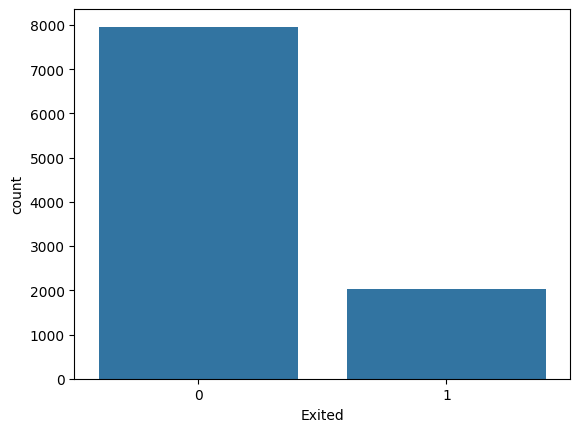

In [82]:
# inspect target results
sns.countplot(x=data['Exited'])

There is a class imbalance issue, with the no. of people exiting 1 quarter that of those that stayed!

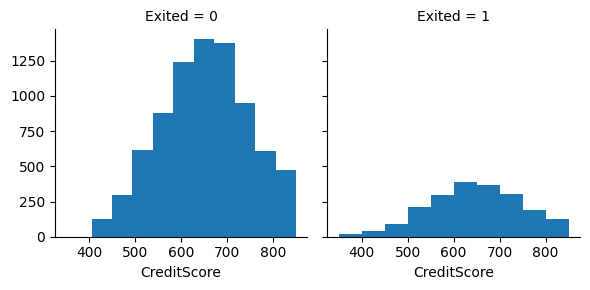

In [83]:
g = sns.FacetGrid(data,col='Exited')
g.map(plt.hist,'CreditScore')

Looks like credit score is a normal distribution, with the center between 600-700 for both classes.

<Axes: xlabel='Geography', ylabel='count'>

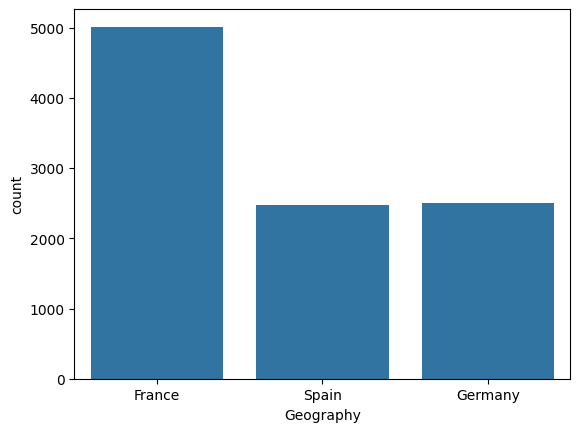

In [84]:
# inspect geography
sns.countplot(x=data['Geography'])

All the customers come from Europe. Most are from France (~50%) while Germany is ~25% and Spain 25%

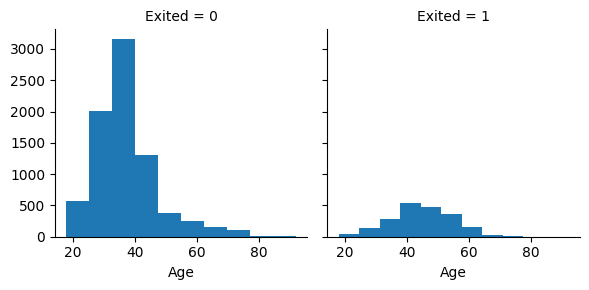

In [85]:
g = sns.FacetGrid(data,col='Exited')
g.map(plt.hist,'Age')

Looks like a majority of the loyal customers are between 20-40 years old

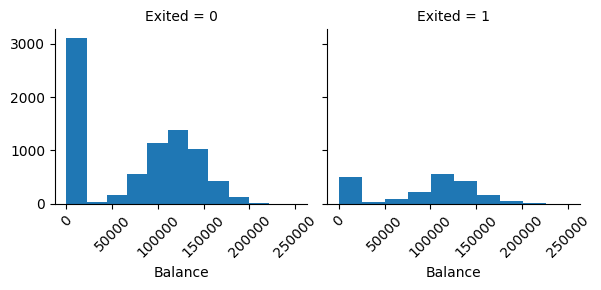

In [86]:
g = sns.FacetGrid(data,col='Exited')
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
g.map(plt.hist,'Balance')

Funny..there are a lot of balances with zero amount!

Start Data Processing

Start separating out the labels column

In [87]:
from sklearn.preprocessing import LabelEncoder
labels = data['Exited']
le = LabelEncoder()
le.fit(labels)
labels = le.transform(labels)
class_names = le.classes_

Drop the columns RowNumber, CustomerId, Surname as they are not predictive features, and remove the labels column

In [88]:
data = data.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis = 1) 
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [89]:
feature_names = data.columns.tolist()

Explicitly define the categorical features, we need this for LIME.
Categorical data: Geography, Gender, HasCrCard, IsActiveMember.

In [90]:
categorical_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']
categorical_names = {}

for feature in categorical_features:    
    le = LabelEncoder()
    data[feature] = le.fit_transform(data[feature])
    categorical_names[feature] = le.classes_

In [91]:
data.head(10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10
5,645,2,1,44,8,113755.78,2,1,0,149756.71
6,822,0,1,50,7,0.00,2,1,1,10062.80
7,376,1,0,29,4,115046.74,4,1,0,119346.88
8,501,0,1,44,4,142051.07,2,0,1,74940.50
9,684,0,1,27,2,134603.88,1,1,1,71725.73


In [92]:

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  int64  
 2   Gender           10000 non-null  int64  
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
dtypes: float64(2), int64(8)
memory usage: 781.4 KB


Ok..now the dataframe has all data as integers/floats, so we are ready to start training the XGBoost classifier!

In [93]:
seed = 101 # fix random seed for reproducibility
np.random.seed(seed)

# Split Train Test sets
from sklearn.model_selection import train_test_split
train, test, labels_train, labels_test = train_test_split(data, labels, 
                                                    test_size=0.2,
                                                    stratify=labels,
                                                    random_state=seed)
print(train.shape, test.shape, labels_train.shape, labels.shape)

(8000, 10) (2000, 10) (8000,) (10000,)


In [94]:
import xgboost
gbtree = xgboost.XGBClassifier(n_estimators=300, seed=seed, scale_pos_weight=4 ,eval_metric="aucpr")
gbtree.fit(train, labels_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [95]:
y_preds = gbtree.predict(test)

In [96]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
def model_evaluate(): 
    
    print('Test Accuracy:\t{:0.1f}%'.format(accuracy_score(labels_test,y_preds)*100))
    
    #classification report
    print('\n')
    print(classification_report(labels_test, y_preds))

    #confusion matrix
    confmat = confusion_matrix(labels_test, y_preds)

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
    for i in range(confmat.shape[0]):
        for j in range(confmat.shape[1]):
            ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()

Test Accuracy:	82.8%


              precision    recall  f1-score   support

           0       0.88      0.91      0.89      1593
           1       0.59      0.52      0.55       407

    accuracy                           0.83      2000
   macro avg       0.73      0.71      0.72      2000
weighted avg       0.82      0.83      0.82      2000



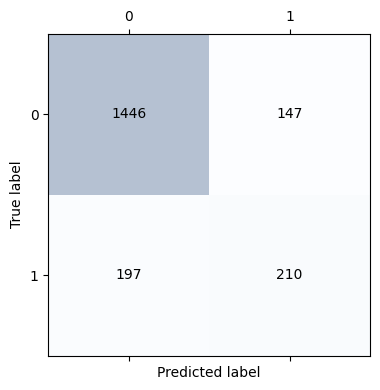

In [97]:
# evaluate model with test set
model_evaluate()

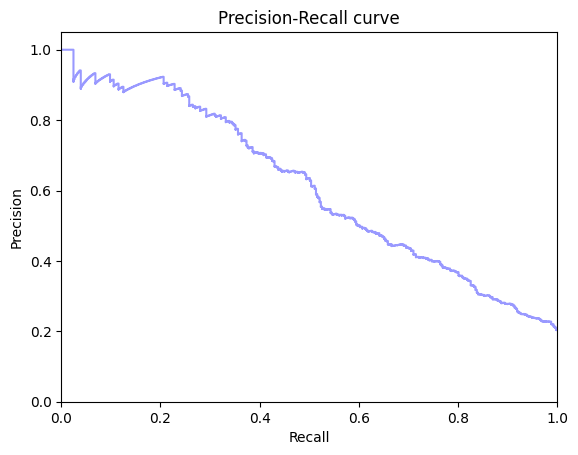

In [98]:
#PLot PR-curve
from sklearn.metrics import precision_recall_curve
y_pred = gbtree.predict_proba(test)
precision, recall, thresholds = precision_recall_curve(labels_test, y_pred[:,1])
 
thresholds = np.append(thresholds, 1)
f1_scores = 2*(precision*recall)/(precision+recall)
plt.step(recall, precision, color='b', alpha=0.4, where='post')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall curve')
plt.show()

This was an imbalanced dataset where the positive cases were much lesser than the negative. Hence for the positive cases, the XGB model gets 50+% of the positive classification correct. There are alot of false negatives & positives.

Let's look at the XGB model global importance features, we'll contrast with LIME local importance later.

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

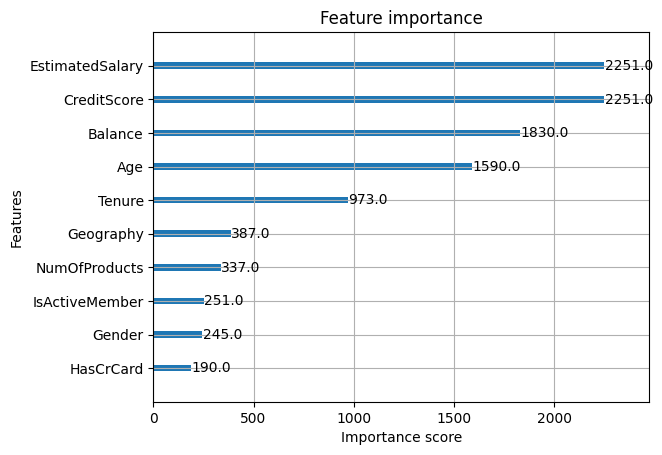

In [99]:
# Feature importance
from xgboost import plot_importance
plot_importance(gbtree)

From a global importance level, it seems the top 3 features are EstimatedSalary, CreditScore & Balance.

Now, let's use LIME!!

In [100]:
import lime.lime_tabular
explainer = lime.lime_tabular.LimeTabularExplainer(train.values ,feature_names = feature_names,class_names=class_names,
                                                   categorical_features=categorical_features, 
                                                   categorical_names=categorical_names, kernel_width=3)

Lime tabular needs a predict function

In [101]:
predict_fn = lambda x: gbtree.predict_proba(x).astype(float)

In [102]:
#Choose a local instance
chosen = test.iloc[111].values.copy()
print(chosen)

[6.5600000e+02 1.0000000e+00 0.0000000e+00 2.3000000e+01 4.0000000e+00
 1.6354963e+05 1.0000000e+00 0.0000000e+00 1.0000000e+00 2.1085120e+04]


In [103]:
print('True class: %s' % class_names[labels_test[111]])

True class: 0


In [104]:
exp = explainer.explain_instance(chosen, predict_fn,num_features=5)
lime_df = pd.DataFrame(
    exp.as_list(),
    columns=['Feature', 'Contribution']
)

print(lime_df)

                         Feature  Contribution
0                   Age <= 32.00     -0.211145
1  0.00 < IsActiveMember <= 1.00     -0.147909
2          NumOfProducts <= 1.00      0.129534
3                 Gender <= 0.00      0.063650
4       0.00 < Geography <= 1.00      0.028074


In [105]:
prob_no_churn = exp.predict_proba[0]
prob_churn = exp.predict_proba[1]

print(f"No Churn Probability: {prob_no_churn:.2%}")
print(f"Churn Probability: {prob_churn:.2%}")

No Churn Probability: 99.92%
Churn Probability: 0.08%


LIME predicts for this local instance, the 2 features that contribute to the classification is Age and IsActiveMember, rather than the 3 global importance features reported by XGBoost. 

## shap

In [106]:
import shap

explainer = shap.TreeExplainer(gbtree)

c:\Users\khank\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\khank\AppData\Local\Temp\ipykernel_30504\4284622975.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, test)


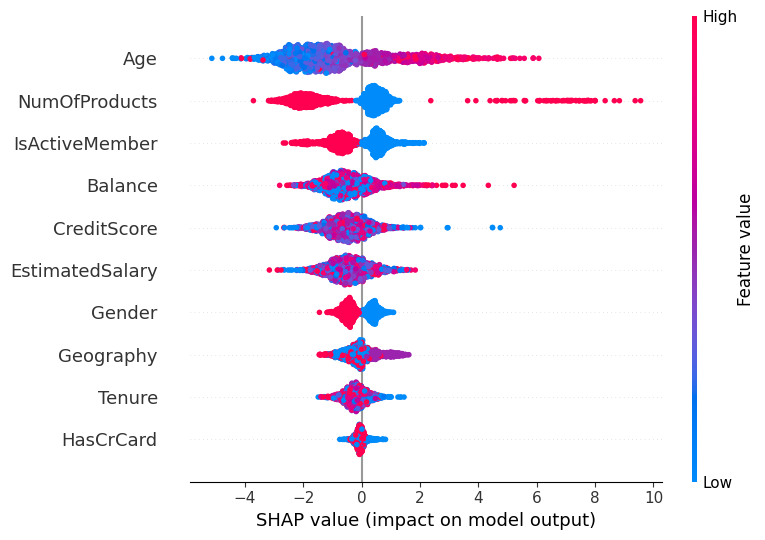

In [108]:
shap_values = explainer.shap_values(test)
shap.summary_plot(shap_values, test)

C:\Users\khank\AppData\Local\Temp\ipykernel_30504\1639522907.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, test, plot_type="bar", color='red')


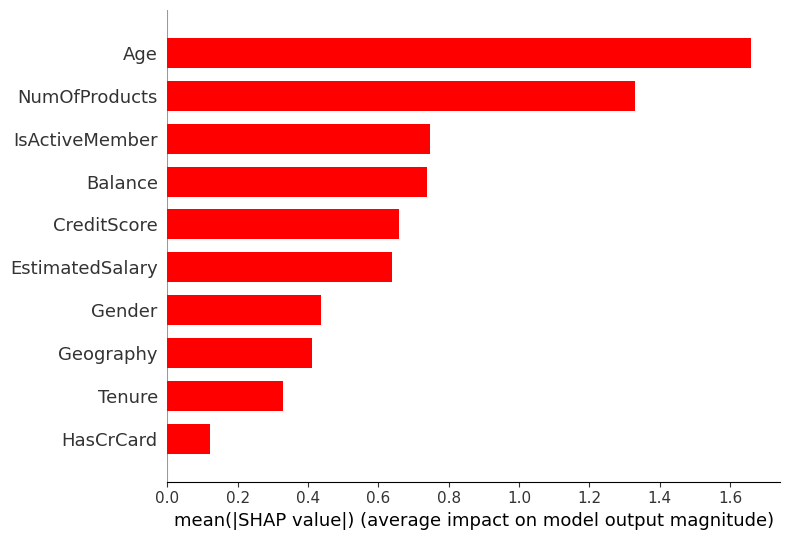

In [109]:
shap.summary_plot(shap_values, test, plot_type="bar", color='red')

In [110]:
customer_index = 0

customer_shap = shap_values[customer_index]

In [112]:
shap_df = pd.DataFrame({
    'Feature': test.columns,
    'SHAP_Value': customer_shap,
    'Feature_Value': test.iloc[customer_index].values
})
shap_df

,Feature,SHAP_Value,Feature_Value
0,CreditScore,0.334538,690.00
1,Geography,-0.275230,0.00
2,Gender,-0.434040,1.00
3,Age,-0.540398,38.00
4,Tenure,-0.572226,1.00
5,Balance,-0.036101,94456.00
6,NumOfProducts,-0.978782,2.00
7,HasCrCard,-0.079178,0.00
8,IsActiveMember,-0.437206,1.00
9,EstimatedSalary,-0.556651,55034.02
